# All Clone Types: Heat-Kernel Similarity Distributions

This notebook compares Type 1, Type 2, Type 3, and Type 4 BigCloneBench pairs using only the heat-kernel spectral metric. It does not use zero padding. Heat-kernel similarity consumes each graph spectrum at its natural length and maps it to fixed time-scale trace features.

In [8]:
from __future__ import annotations

import json
import pickle
import random
import sys
from dataclasses import dataclass
from pathlib import Path

import matplotlib.pyplot as plt
import numpy as np
import pandas as pd
import seaborn as sns
from tqdm.auto import tqdm

PROJECT_ROOT = Path.cwd()
if PROJECT_ROOT.name != "Spectral-Software":
    matches = [p for p in [PROJECT_ROOT, *PROJECT_ROOT.parents] if p.name == "Spectral-Software"]
    if not matches:
        raise RuntimeError("Run this notebook from inside the Spectral-Software project.")
    PROJECT_ROOT = matches[0]

if str(PROJECT_ROOT) not in sys.path:
    sys.path.append(str(PROJECT_ROOT))

from spectral_code.similarity.heat_kernel import HeatKernelSimilarity

sns.set_theme(style="whitegrid", context="notebook")
pd.set_option("display.max_columns", 100)

PROJECT_ROOT

WindowsPath('c:/Users/koush/PyProjects/Spectral-Software')

In [9]:
CLONE_TYPES = [1, 2, 3, 4]
GRAPH_TYPES = ["ast", "cfg", "ddg", "pdg", "cpg"]

BENCH_ROOT = PROJECT_ROOT / "bench_data"
OUTPUTS_ROOT = PROJECT_ROOT.parent / "outputs"
ANALYSIS_OUT = PROJECT_ROOT / "notebooks" / "analysis" / "outputs" / "heatkernel_all_types"
ANALYSIS_OUT.mkdir(parents=True, exist_ok=True)

# None means use the full train.txt for every type.
# Set to an integer such as 20_000 for a faster exploratory run.
MAX_PAIRS_PER_TYPE = None
RANDOM_SEED = 42

# Keep false for the least biased distribution plot. Empty spectra are still dropped.
DROP_ALL_ZERO_SPECTRA = False

TIME_SCALES = [0.1, 0.5, 1.0, 2.0, 5.0, 10.0]
metric = HeatKernelSimilarity(time_scales=TIME_SCALES)

print(f"Bench root:   {BENCH_ROOT}")
print(f"Outputs root: {OUTPUTS_ROOT}")
print(f"Analysis out: {ANALYSIS_OUT}")

Bench root:   c:\Users\koush\PyProjects\Spectral-Software\bench_data
Outputs root: c:\Users\koush\PyProjects\outputs
Analysis out: c:\Users\koush\PyProjects\Spectral-Software\notebooks\analysis\outputs\heatkernel_all_types


In [10]:
@dataclass(frozen=True)
class PairRow:
    left_id: int
    right_id: int
    label: int


def load_train_pairs(data_dir: Path) -> list[PairRow]:
    path = data_dir / "train.txt"
    if not path.exists():
        raise FileNotFoundError(path)

    pairs: list[PairRow] = []
    with path.open("r", encoding="utf-8") as f:
        for line in f:
            left, right, label = line.rstrip("\n").split("\t")
            pairs.append(PairRow(int(left), int(right), int(label)))
    return pairs


def sample_pairs(pairs: list[PairRow], max_pairs: int | None, seed: int) -> list[PairRow]:
    if max_pairs is None or max_pairs >= len(pairs):
        return pairs
    rng = random.Random(seed)
    return rng.sample(pairs, max_pairs)


def needed_method_ids(pairs: list[PairRow]) -> set[str]:
    ids: set[str] = set()
    for pair in pairs:
        ids.add(str(pair.left_id))
        ids.add(str(pair.right_id))
    return ids


def load_feature_records(manifest_path: Path, needed_ids: set[str]) -> dict[str, dict]:
    if not manifest_path.exists():
        raise FileNotFoundError(manifest_path)

    with manifest_path.open("r", encoding="utf-8") as f:
        manifest = json.load(f)

    if manifest.get("format") != "spectral_feature_shards_v1":
        raise ValueError(f"Unsupported spectral feature manifest: {manifest_path}")

    records: dict[str, dict] = {}
    for shard_path in tqdm(manifest["shards"], desc=f"Loading {manifest_path.parent.parent.name} shards", unit="shard"):
        with Path(shard_path).open("rb") as f:
            shard = pickle.load(f)

        for method_id, record in shard.items():
            method_key = str(method_id)
            if method_key in needed_ids:
                records[method_key] = record

        if len(records) >= len(needed_ids):
            break

    return records


def get_eigenvalues(features: dict[str, dict], method_id: int, graph_type: str) -> np.ndarray | None:
    record = features.get(str(method_id))
    if not record:
        return None

    values = record.get(graph_type, {}).get("eigenvalues", np.array([]))
    values = np.asarray(values, dtype=np.float64)
    if values.size == 0 or not np.all(np.isfinite(values)):
        return None
    if DROP_ALL_ZERO_SPECTRA and not np.any(np.abs(values) > 1e-10):
        return None
    return values


def score_type_graph(clone_type: int, graph_type: str, pairs: list[PairRow], features: dict[str, dict]) -> tuple[pd.DataFrame, dict]:
    rows = []
    dropped_missing = 0

    for pair in tqdm(pairs, desc=f"Type {clone_type} {graph_type.upper()}", leave=False):
        left_ev = get_eigenvalues(features, pair.left_id, graph_type)
        right_ev = get_eigenvalues(features, pair.right_id, graph_type)

        if left_ev is None or right_ev is None:
            dropped_missing += 1
            continue

        rows.append({
            "clone_type": f"type{clone_type}",
            "clone_type_num": clone_type,
            "graph_type": graph_type,
            "left_id": pair.left_id,
            "right_id": pair.right_id,
            "label": pair.label,
            "class": "clone" if pair.label == 1 else "non_clone",
            "score": metric.compute(left_ev, right_ev),
            "left_spectrum_len": int(left_ev.size),
            "right_spectrum_len": int(right_ev.size),
        })

    diagnostics = {
        "clone_type": f"type{clone_type}",
        "graph_type": graph_type,
        "input_pairs": len(pairs),
        "scored_pairs": len(rows),
        "dropped_missing_or_empty_spectra": dropped_missing,
    }
    return pd.DataFrame(rows), diagnostics

In [11]:
all_scores = []
all_diagnostics = []

for clone_type in CLONE_TYPES:
    data_dir = BENCH_ROOT / f"bcb_full_type{clone_type}"
    manifest_path = OUTPUTS_ROOT / f"type{clone_type}" / "spectral_features" / "spectral_features_manifest.json"

    pairs = load_train_pairs(data_dir)
    pairs = sample_pairs(pairs, MAX_PAIRS_PER_TYPE, RANDOM_SEED + clone_type)
    ids = needed_method_ids(pairs)

    print(f"\nType {clone_type}: {len(pairs):,} pairs, {len(ids):,} needed methods")
    features = load_feature_records(manifest_path, ids)
    print(f"Type {clone_type}: loaded {len(features):,} feature records")

    for graph_type in GRAPH_TYPES:
        score_df, diagnostics = score_type_graph(clone_type, graph_type, pairs, features)
        all_scores.append(score_df)
        all_diagnostics.append(diagnostics)

scores_df = pd.concat(all_scores, ignore_index=True)
diagnostics_df = pd.DataFrame(all_diagnostics)

scores_path = ANALYSIS_OUT / "all_types_heatkernel_scores.csv"
diagnostics_path = ANALYSIS_OUT / "all_types_heatkernel_diagnostics.csv"
scores_df.to_csv(scores_path, index=False)
diagnostics_df.to_csv(diagnostics_path, index=False)

print(f"Saved scores:      {scores_path}")
print(f"Saved diagnostics: {diagnostics_path}")
display(diagnostics_df)


Type 1: 100,000 pairs, 107,413 needed methods


Loading type1 shards:   0%|          | 0/108 [00:00<?, ?shard/s]

Type 1: loaded 107,368 feature records


Type 1 AST:   0%|          | 0/100000 [00:00<?, ?it/s]

Type 1 CFG:   0%|          | 0/100000 [00:00<?, ?it/s]

...

Type 4 DDG:   0%|          | 0/100000 [00:00<?, ?it/s]

Type 4 PDG:   0%|          | 0/100000 [00:00<?, ?it/s]

Type 4 CPG:   0%|          | 0/100000 [00:00<?, ?it/s]

Saved scores:      c:\Users\koush\PyProjects\Spectral-Software\notebooks\analysis\outputs\heatkernel_all_types\all_types_heatkernel_scores.csv
Saved diagnostics: c:\Users\koush\PyProjects\Spectral-Software\notebooks\analysis\outputs\heatkernel_all_types\all_types_heatkernel_diagnostics.csv


,clone_type,graph_type,input_pairs,scored_pairs,dropped_missing_or_empty_spectra
0,type1,ast,100000,90146,9854
1,type1,cfg,100000,90145,9855
2,type1,ddg,100000,90097,9903
3,type1,pdg,100000,90097,9903
4,type1,cpg,100000,90146,9854
5,type2,ast,100000,94496,5504
6,type2,cfg,100000,94495,5505
7,type2,ddg,100000,94397,5603
8,type2,pdg,100000,94397,5603
9,type2,cpg,100000,94496,5504


In [12]:
def q05(x): return x.quantile(0.05)
def q25(x): return x.quantile(0.25)
def q75(x): return x.quantile(0.75)
def q95(x): return x.quantile(0.95)

summary_df = (
    scores_df
    .groupby(["clone_type", "graph_type", "class"], as_index=False)
    .agg(
        n=("score", "size"),
        mean=("score", "mean"),
        median=("score", "median"),
        std=("score", "std"),
        q05=("score", q05),
        q25=("score", q25),
        q75=("score", q75),
        q95=("score", q95),
        mean_left_spectrum_len=("left_spectrum_len", "mean"),
        mean_right_spectrum_len=("right_spectrum_len", "mean"),
    )
    .sort_values(["clone_type", "graph_type", "class"])
)

summary_path = ANALYSIS_OUT / "all_types_heatkernel_distribution_summary.csv"
summary_df.to_csv(summary_path, index=False)
print(f"Saved summary: {summary_path}")
display(summary_df)

Saved summary: c:\Users\koush\PyProjects\Spectral-Software\notebooks\analysis\outputs\heatkernel_all_types\all_types_heatkernel_distribution_summary.csv


,clone_type,graph_type,class,n,mean,median,std,q05,q25,q75,q95,mean_left_spectrum_len,mean_right_spectrum_len
0,type1,ast,clone,40914,1.000000,1.000000,8.505026e-17,1.000000,1.000000,1.000000,1.000000,77.247910,77.247910
1,type1,ast,non_clone,49232,0.967643,0.971451,2.361466e-02,0.925064,0.951664,0.987494,0.997311,36.638325,36.059514
2,type1,cfg,clone,40914,1.000000,1.000000,1.885953e-16,1.000000,1.000000,1.000000,1.000000,29.768392,29.768392
3,type1,cfg,non_clone,49231,0.910266,0.939476,1.048215e-01,0.592106,0.878392,0.978149,1.000000,14.618655,14.502062
4,type1,cpg,clone,40914,1.000000,1.000000,2.409979e-06,1.000000,1.000000,1.000000,1.000000,77.247910,77.247910
5,type1,cpg,non_clone,49232,0.968265,0.972334,2.260886e-02,0.926157,0.953191,0.986899,0.996492,36.644317,36.066217
6,type1,ddg,clone,40914,1.000000,1.000000,2.253512e-06,1.000000,1.000000,1.000000,1.000000,30.623503,30.623698
7,type1,ddg,non_clone,49183,0.947250,0.952751,3.957607e-02,0.880510,0.917623,0.978926,1.000000,14.497774,14.314174
8,type1,pdg,clone,40914,1.000000,1.000000,4.375241e-06,1.000000,1.000000,1.000000,1.000000,31.483111,31.483111
9,type1,pdg,non_clone,49183,0.945791,0.951630,4.066032e-02,0.878180,0.916199,0.978685,1.000000,15.536669,15.388956


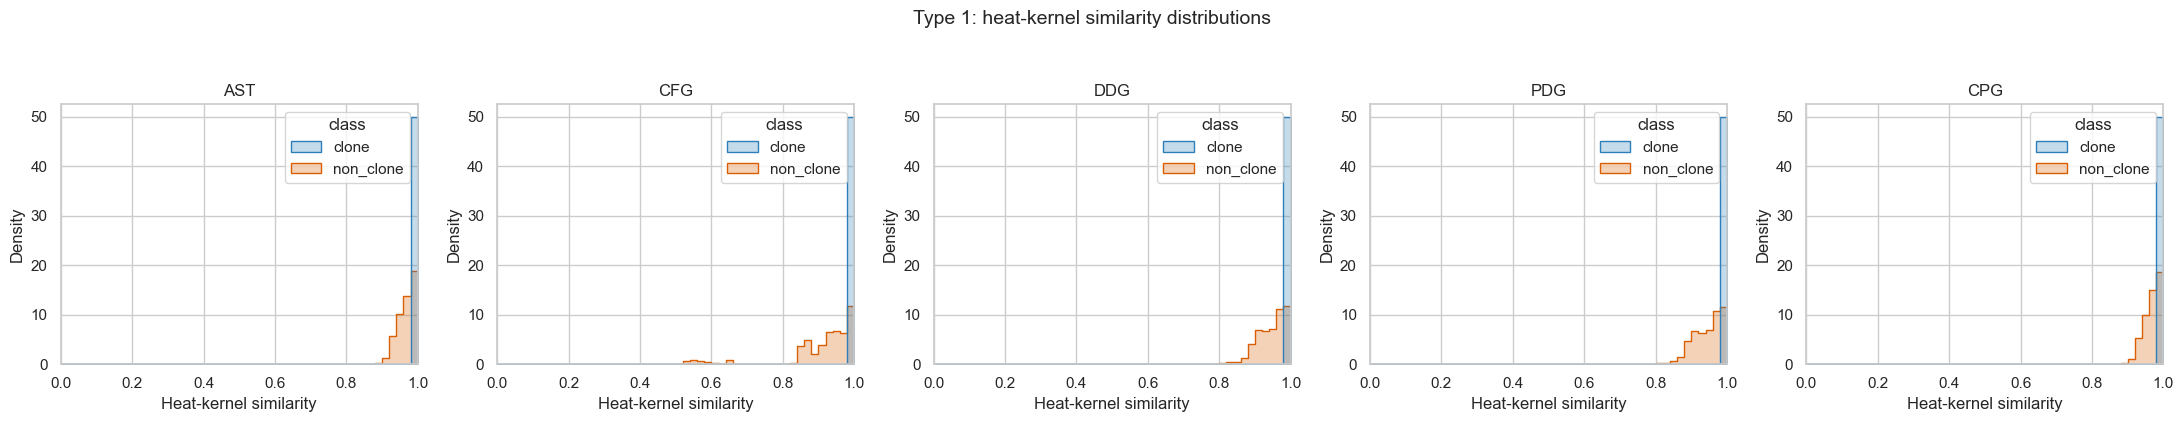

Saved: c:\Users\koush\PyProjects\Spectral-Software\notebooks\analysis\outputs\heatkernel_all_types\type1_heatkernel_distributions.png


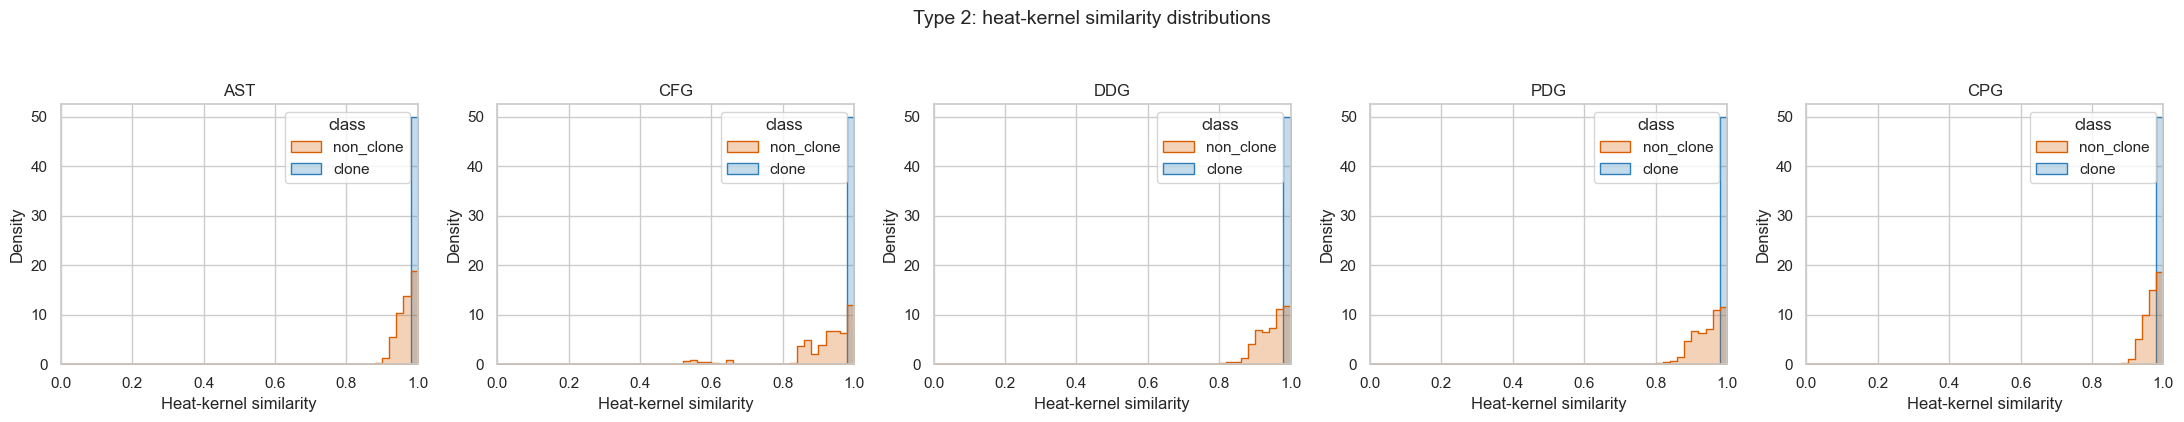

Saved: c:\Users\koush\PyProjects\Spectral-Software\notebooks\analysis\outputs\heatkernel_all_types\type2_heatkernel_distributions.png


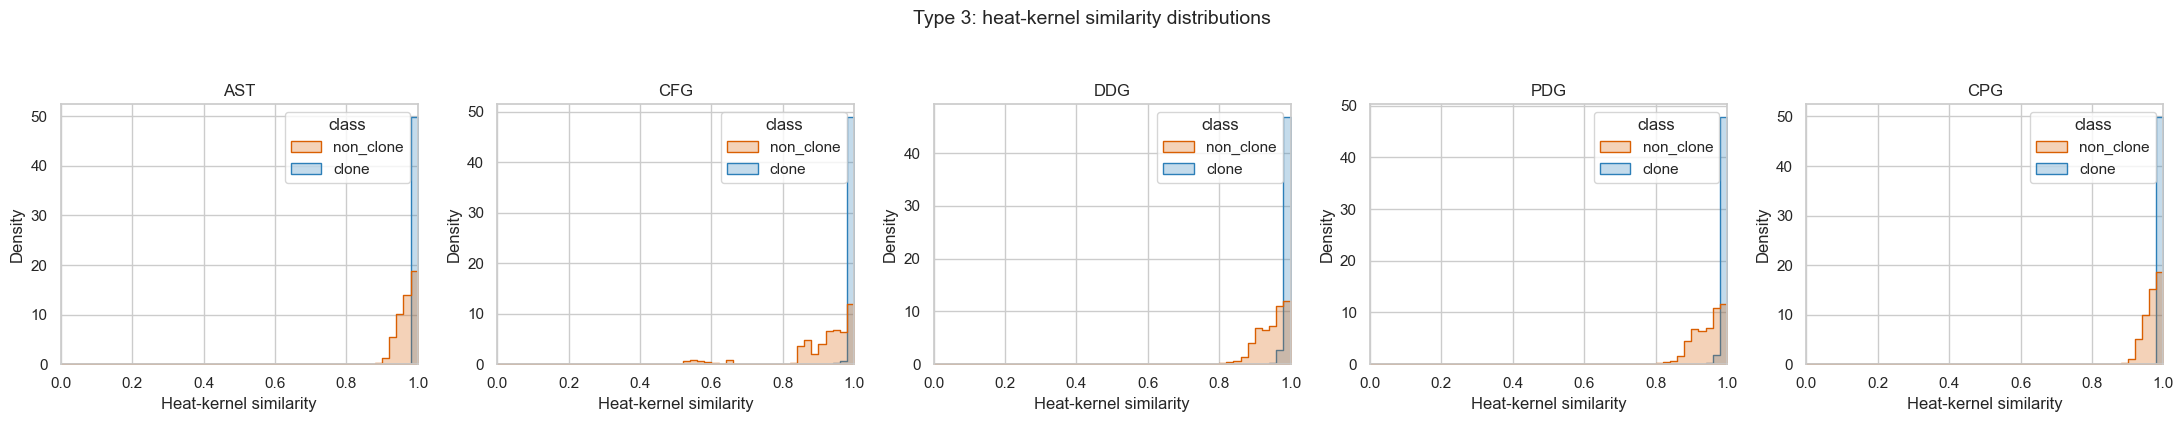

Saved: c:\Users\koush\PyProjects\Spectral-Software\notebooks\analysis\outputs\heatkernel_all_types\type3_heatkernel_distributions.png


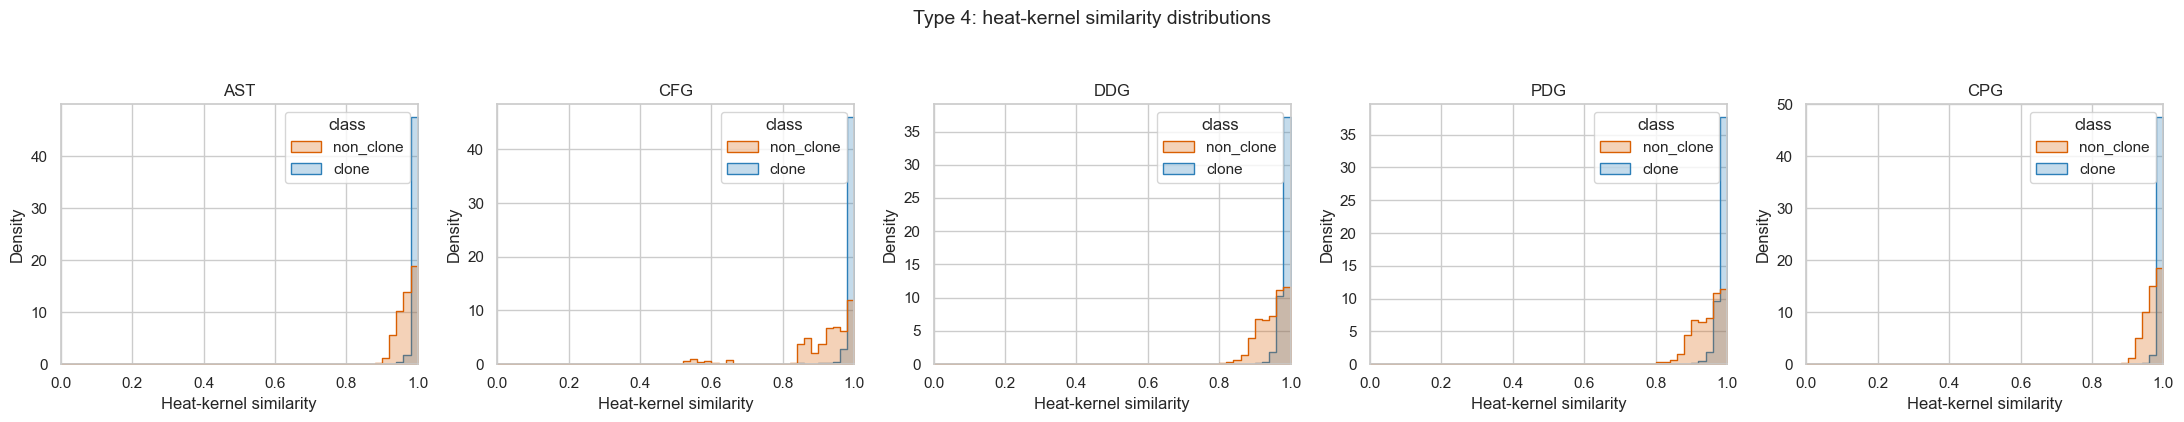

Saved: c:\Users\koush\PyProjects\Spectral-Software\notebooks\analysis\outputs\heatkernel_all_types\type4_heatkernel_distributions.png


In [13]:
palette = {"clone": "#2c7fb8", "non_clone": "#d95f02"}

for clone_type in CLONE_TYPES:
    type_df = scores_df[scores_df["clone_type_num"] == clone_type]
    if type_df.empty:
        continue

    fig, axes = plt.subplots(1, len(GRAPH_TYPES), figsize=(22, 4), sharex=True, sharey=False)
    for ax, graph_type in zip(axes, GRAPH_TYPES):
        plot_df = type_df[type_df["graph_type"] == graph_type]
        if plot_df.empty:
            ax.set_title(graph_type.upper())
            ax.set_axis_off()
            continue

        sns.histplot(
            data=plot_df,
            x="score",
            hue="class",
            bins=50,
            binrange=(0.0, 1.0),
            stat="density",
            common_norm=False,
            element="step",
            fill=True,
            alpha=0.28,
            palette=palette,
            ax=ax,
        )
        ax.set_title(graph_type.upper())
        ax.set_xlim(0.0, 1.0)
        ax.set_xlabel("Heat-kernel similarity")
        ax.set_ylabel("Density")

    fig.suptitle(f"Type {clone_type}: heat-kernel similarity distributions", y=1.05, fontsize=14)
    fig.tight_layout()
    out_path = ANALYSIS_OUT / f"type{clone_type}_heatkernel_distributions.png"
    fig.savefig(out_path, dpi=160, bbox_inches="tight")
    plt.show()
    print(f"Saved: {out_path}")

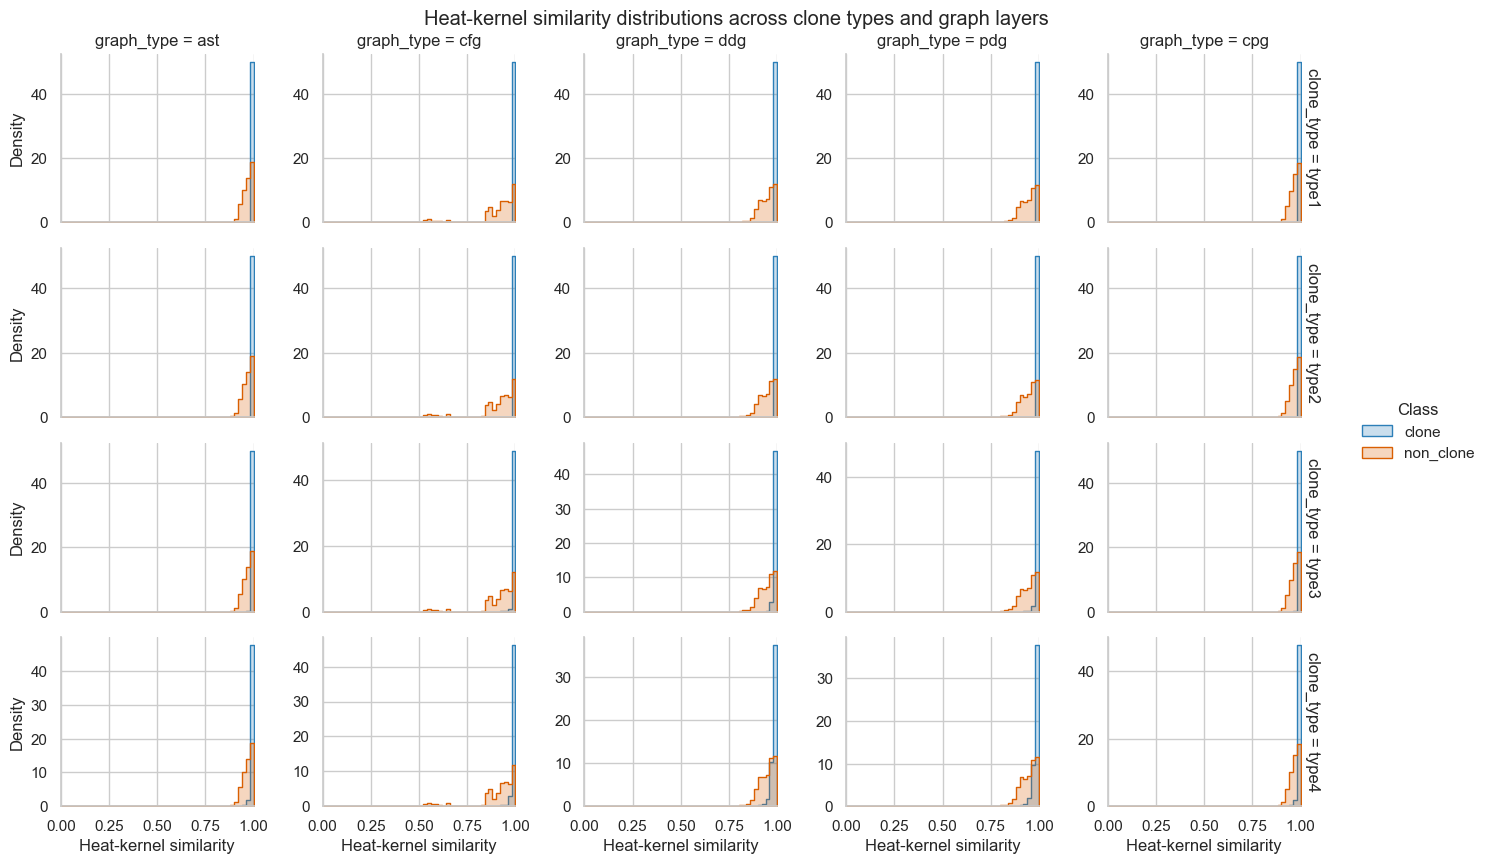

Saved: c:\Users\koush\PyProjects\Spectral-Software\notebooks\analysis\outputs\heatkernel_all_types\all_types_heatkernel_distribution_grid.png


In [14]:
grid = sns.FacetGrid(
    scores_df,
    row="clone_type",
    col="graph_type",
    hue="class",
    hue_order=["clone", "non_clone"],
    palette=palette,
    margin_titles=True,
    height=2.2,
    aspect=1.25,
    sharex=True,
    sharey=False,
)
grid.map_dataframe(
    sns.histplot,
    x="score",
    bins=50,
    binrange=(0.0, 1.0),
    stat="density",
    common_norm=False,
    element="step",
    fill=True,
    alpha=0.25,
)
grid.set_axis_labels("Heat-kernel similarity", "Density")
grid.set(xlim=(0.0, 1.0))
grid.add_legend(title="Class")
grid.fig.subplots_adjust(top=0.93)
grid.fig.suptitle("Heat-kernel similarity distributions across clone types and graph layers")

facet_path = ANALYSIS_OUT / "all_types_heatkernel_distribution_grid.png"
grid.fig.savefig(facet_path, dpi=160, bbox_inches="tight")
plt.show()
print(f"Saved: {facet_path}")

In [15]:
def candidate_thresholds(scores: np.ndarray) -> np.ndarray:
    unique_scores = np.unique(scores)
    candidates = {0.0, 1.0}
    candidates.update(float(score) for score in unique_scores)

    if len(unique_scores) > 1:
        mids = (unique_scores[:-1] + unique_scores[1:]) / 2.0
        candidates.update(float(th) for th in mids)

    return np.array(sorted(candidates), dtype=np.float64)


def best_binary_threshold(group: pd.DataFrame) -> pd.Series:
    labels = group["label"].to_numpy(dtype=np.int64)
    scores = group["score"].to_numpy(dtype=np.float64)

    if len(np.unique(labels)) < 2:
        return pd.Series({
            "best_threshold": np.nan,
            "accuracy": np.nan,
            "precision": np.nan,
            "recall": np.nan,
            "f1": np.nan,
            "valid_pairs": len(group),
            "clone_pairs": int(np.sum(labels == 1)),
            "nonclone_pairs": int(np.sum(labels == 0)),
        })

    best = None
    for th in candidate_thresholds(scores):
        preds = (scores >= th).astype(np.int64)
        tp = int(np.sum((preds == 1) & (labels == 1)))
        fp = int(np.sum((preds == 1) & (labels == 0)))
        tn = int(np.sum((preds == 0) & (labels == 0)))
        fn = int(np.sum((preds == 0) & (labels == 1)))

        accuracy = (tp + tn) / len(labels)
        precision = tp / (tp + fp) if (tp + fp) else 0.0
        recall = tp / (tp + fn) if (tp + fn) else 0.0
        f1 = (2 * precision * recall / (precision + recall)) if (precision + recall) else 0.0

        row = (accuracy, f1, th, precision, recall, tp, fp, tn, fn)
        if best is None or row[:3] > best[:3]:
            best = row

    accuracy, f1, th, precision, recall, tp, fp, tn, fn = best
    return pd.Series({
        "best_threshold": float(th),
        "accuracy": float(accuracy),
        "precision": float(precision),
        "recall": float(recall),
        "f1": float(f1),
        "valid_pairs": len(group),
        "clone_pairs": int(np.sum(labels == 1)),
        "nonclone_pairs": int(np.sum(labels == 0)),
        "tp": tp,
        "fp": fp,
        "tn": tn,
        "fn": fn,
    })


accuracy_df = (
    scores_df
    .groupby(["clone_type", "graph_type"], group_keys=False)
    .apply(best_binary_threshold)
    .reset_index()
    .sort_values(["clone_type", "accuracy", "f1"], ascending=[True, False, False])
)

accuracy_path = ANALYSIS_OUT / "all_types_heatkernel_accuracy_by_type_graph.csv"
accuracy_df.to_csv(accuracy_path, index=False)
print(f"Saved accuracy table: {accuracy_path}")
display(accuracy_df)

Saved accuracy table: c:\Users\koush\PyProjects\Spectral-Software\notebooks\analysis\outputs\heatkernel_all_types\all_types_heatkernel_accuracy_by_type_graph.csv


,clone_type,graph_type,best_threshold,accuracy,precision,recall,f1,valid_pairs,clone_pairs,nonclone_pairs,tp,fp,tn,fn
2,type1,cpg,1.000000,0.991824,0.982908,0.999365,0.991068,90146.0,40914.0,49232.0,40888.0,711.0,48521.0,26.0
0,type1,ast,1.000000,0.988119,0.974785,0.999682,0.987077,90146.0,40914.0,49232.0,40901.0,1058.0,48174.0,13.0
4,type1,pdg,1.000000,0.975637,0.954246,0.994012,0.973723,90097.0,40914.0,49183.0,40669.0,1950.0,47233.0,245.0
3,type1,ddg,1.000000,0.973207,0.947134,0.996627,0.971250,90097.0,40914.0,49183.0,40776.0,2276.0,46907.0,138.0
1,type1,cfg,1.000000,0.958545,0.926488,0.986973,0.955775,90145.0,40914.0,49231.0,40381.0,3204.0,46027.0,533.0
7,type2,cpg,1.000000,0.990529,0.810011,0.994124,0.892673,94496.0,3744.0,90752.0,3722.0,873.0,89879.0,22.0
5,type2,ast,1.000000,0.984222,0.716510,0.995726,0.833352,94496.0,3744.0,90752.0,3728.0,1475.0,89277.0,16.0
8,type2,ddg,1.000000,0.979321,0.670667,0.940438,0.782966,94397.0,3744.0,90653.0,3521.0,1729.0,88924.0,223.0
9,type2,pdg,1.000000,0.978887,0.663737,0.947917,0.780772,94397.0,3744.0,90653.0,3549.0,1798.0,88855.0,195.0
6,type2,cfg,1.000000,0.968453,0.565561,0.879006,0.688278,94495.0,3744.0,90751.0,3291.0,2528.0,88223.0,453.0


In [16]:
mean_gap_df = summary_df.pivot_table(
    index=["clone_type", "graph_type"],
    columns="class",
    values="mean",
).reset_index()

mean_gap_df.columns.name = None
for required_col in ["clone", "non_clone"]:
    if required_col not in mean_gap_df.columns:
        mean_gap_df[required_col] = np.nan

mean_gap_df["clone_minus_nonclone_mean"] = mean_gap_df["clone"] - mean_gap_df["non_clone"]
mean_gap_df = mean_gap_df.sort_values("clone_minus_nonclone_mean", ascending=False)

gap_path = ANALYSIS_OUT / "all_types_heatkernel_mean_gaps.csv"
mean_gap_df.to_csv(gap_path, index=False)
print(f"Saved mean gaps: {gap_path}")
display(mean_gap_df)

Saved mean gaps: c:\Users\koush\PyProjects\Spectral-Software\notebooks\analysis\outputs\heatkernel_all_types\all_types_heatkernel_mean_gaps.csv


,clone_type,graph_type,clone,non_clone,clone_minus_nonclone_mean
1,type1,cfg,1.000000,0.910266,0.089734
6,type2,cfg,1.000000,0.910898,0.089102
11,type3,cfg,0.994976,0.910785,0.084192
16,type4,cfg,0.989639,0.911322,0.078317
9,type2,pdg,1.000000,0.945683,0.054317
4,type1,pdg,1.000000,0.945791,0.054209
8,type2,ddg,1.000000,0.947156,0.052844
3,type1,ddg,1.000000,0.947250,0.052750
14,type3,pdg,0.993147,0.945856,0.047291
13,type3,ddg,0.992645,0.947330,0.045314
